# ✈️ Project: Anomaly Detection on Aircraft Window Sensors

**Students:** EL ARBI ABOULAZ, Jose GARNICA-AZA, William MONCADA 

**Date:** January 2025

---

## 1. Context and Problem Formulation

A plane records a total of 11 features such as speed, temperature, pressure, electrical current values.... For reasons of anonymisation we do not know the meaning of these features. However, We do have an index that represents the time dimension day-cycle-window.


### 1.1 Understanding the Task
We started by exploring the dataset (`dataset.csv`). It contains sensor readings (`p1` to `p11`) for various flight windows, but there is **no "Target" column**. We don't know which flights are broken and which are fine.

| Question | Answer |
|----------|--------|
| **Problem Type?** | **Unsupervised Learning** (No labels provided) |
| **Goal?** | **Outlier Detection** (Identify rare, abnormal events) |
| **Hypothesis?** | Anomalies have a distinct signal shape compared to the fleet average. |

### 1.2 Our Analysis Pipeline
To solve this, we designed a logical strategy:
1.  **Visual Exploration:** Look at the raw signals to understand the physics (trends, noise).
2.  **Preliminary Check:** Test if simple PCA works on raw data.
3.  **Core Solution:** Since data is complex, use Feature Engineering (Slope, Volatility).
4.  **Modeling & Validation:** Isolation Forest + Deep Learning.

### 1.3 Exploratory Data Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from bokeh.models import ColumnDataSource, DataTable, TableColumn
from bokeh.io import show, output_notebook
from bokeh.plotting import figure, show
from bokeh.layouts import gridplot
from bokeh.io import output_notebook
import numpy as np

# Imports for Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Plot configuration
sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load Data
url = "https://raw.githubusercontent.com/jgarnicaa/SUPAERO-machine-learning/refs/heads/main/13%20-%20Anomaly%20Detection/data/dataset.csv"
df = pd.read_csv(url)
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (162702, 12)


#### Quality and Statistical Review

In [28]:
output_notebook()

print("|----------- NAN VALUES PER COLUMN: -----------|")
info_df = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum(),
    "null_count": df.isnull().sum()
})

source = ColumnDataSource(info_df)

columns = [
    TableColumn(field=col, title=col)
    for col in info_df.columns
]

table_info = DataTable(
    source=source,
    columns=columns,
    width=900,
    height=300,
    index_position=None
)

show(table_info)



print("\n|----------- DATAFRAME DESCRIPTION: -----------|")
# df.describe()
desc = df.describe().round(3).reset_index()
source = ColumnDataSource(desc)
columns = [
    TableColumn(field=col, title=col)
    for col in desc.columns
]

table = DataTable(
    source=source,
    columns=columns,
    width=900,
    height=300,
    index_position=None
)

show(table)

Loading BokehJS ...

|----------- NAN VALUES PER COLUMN: -----------|



|----------- DATAFRAME DESCRIPTION: -----------|


<div class="alert alert-success">

**NOTE** <br>
By looking at the describe and info functions, we can see that there is not non applicable values. Dataset is standardise with zero mean unit variance and all variables are of type float64. The quality of the data is good overall, few data pre-processing will be needed.

</div>

### Data Visualization

In [29]:
output_notebook()

variables = [col for col in df.columns if col.startswith('p')]

plots = []

for var in variables:
    hist, edges = np.histogram(df[var].dropna(), bins=30)

    p = figure(
        title=f"Histogram of {var}",
        width=300,
        height=250,
        tools="pan,wheel_zoom,box_zoom,reset,hover",
        tooltips=[
            ("Range", "@left{0.00} – @right{0.00}"),
            ("Count", "@top")
        ]
    )

    p.quad(
        top=hist,
        bottom=0,
        left=edges[:-1],
        right=edges[1:],
        fill_color="navy",
        line_color="white",
        alpha=0.7
    )

    p.xaxis.axis_label = var
    p.yaxis.axis_label = "Count"

    plots.append(p)

grid = gridplot(plots, ncols=4)

show(grid)


Loading BokehJS ...

<div class="alert alert-success">

**NOTE** <br>
By watching these histograms, we can see that all of them seems to be gaussian values. The sensor distributions appear approximately centered around zero and exhibit comparable scales, which is consistent with a standardization preprocessing step.

</div>

---

## 2. Visual Exploration: Defining "Normal"

Before running any algorithms, we need to understand what a "normal" flight looks like.
We plot the 11 sensors for a few random windows to identify characteristics like trends or noise.

Let's look at 3 random 'Normal' examples:


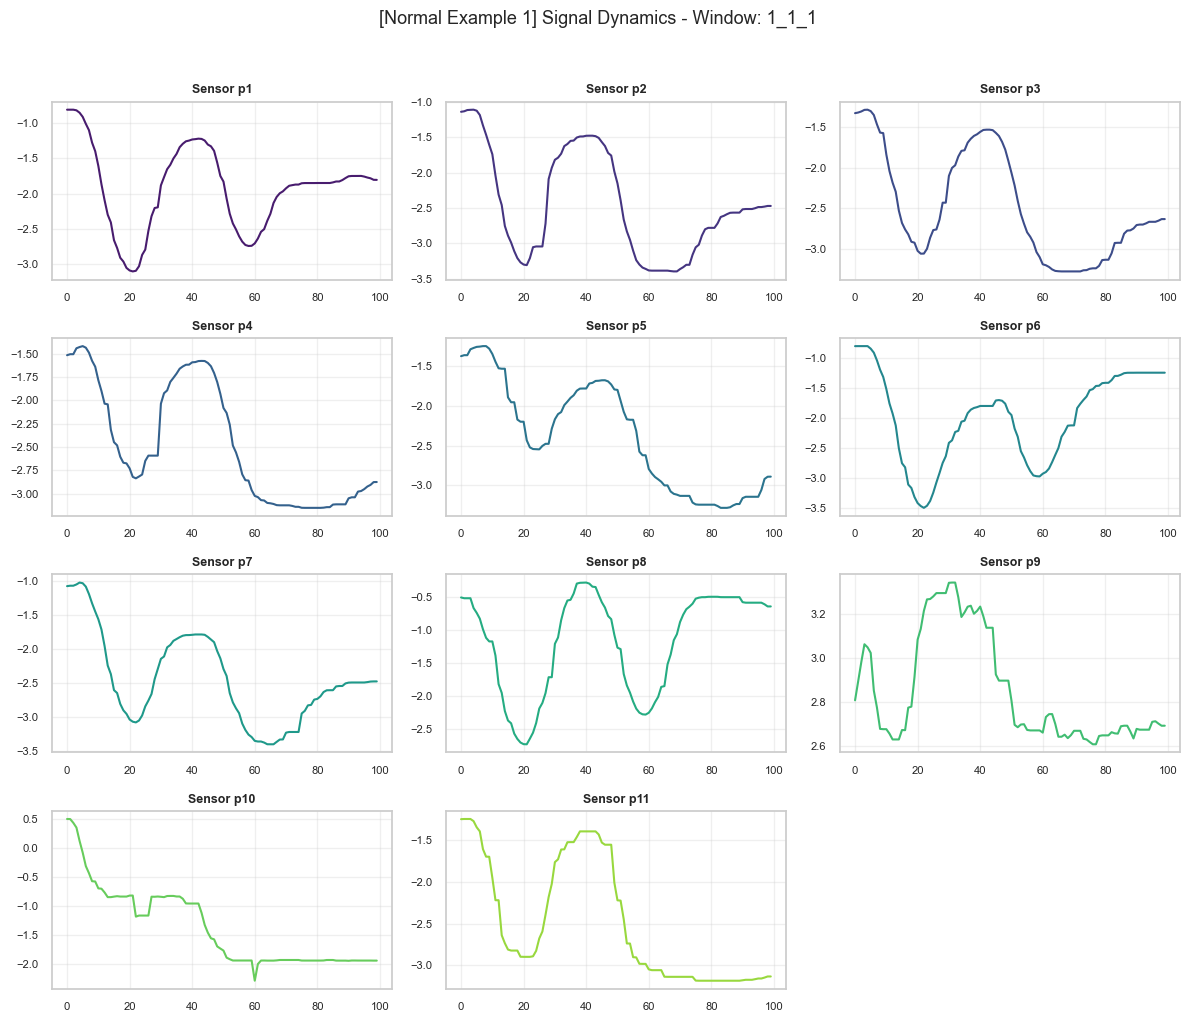

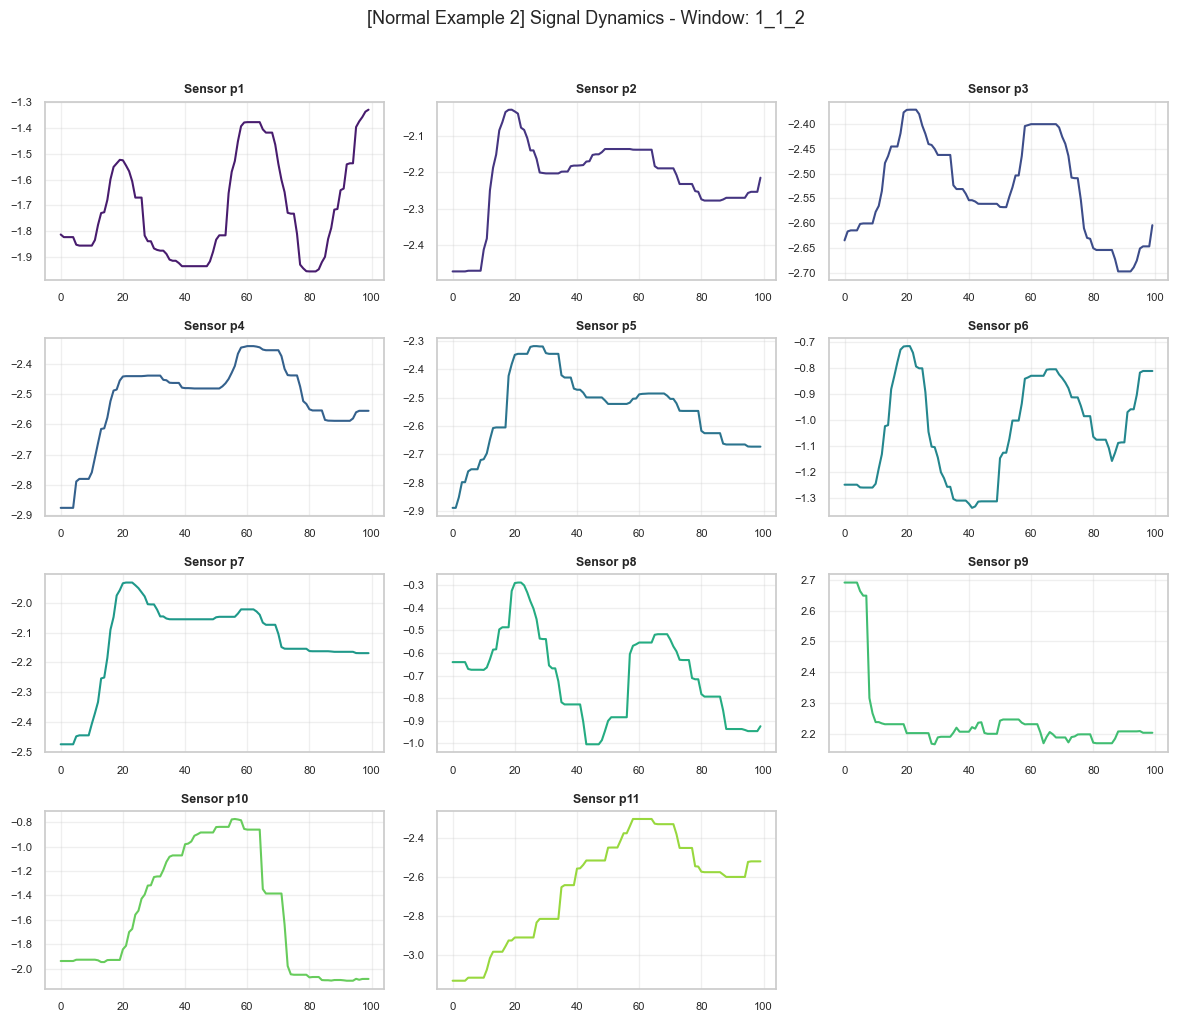

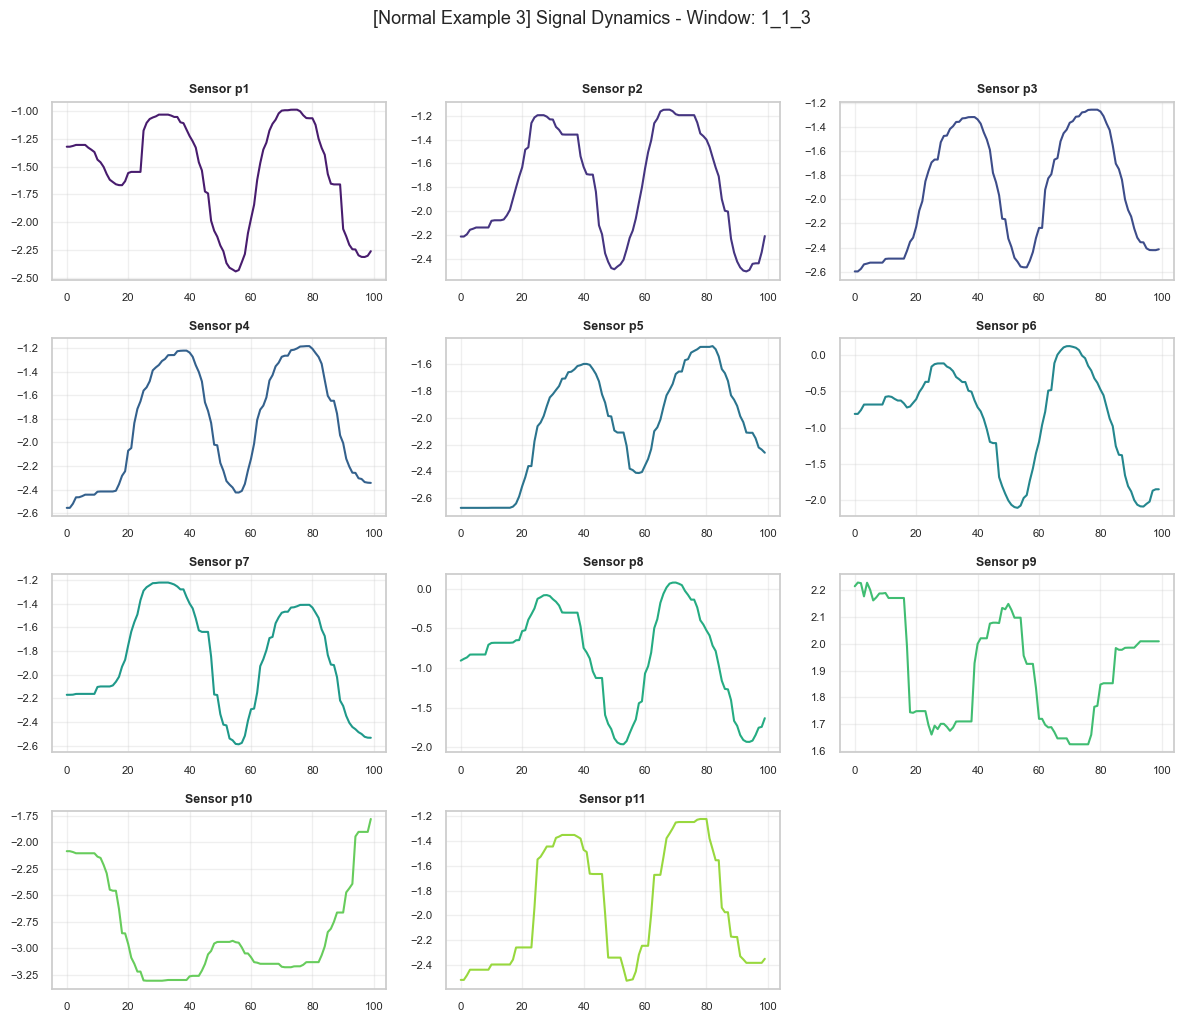

In [30]:
def plot_window_dynamics(df, window_id, title_prefix=""):
    """ 
    Helper function to plot the 11 sensors for a single window.
    This helps us visualize the physics of the flight.
    """
    data = df[df['day_cycle_window'] == window_id].reset_index(drop=True)
    if data.empty: return

    # Creating a grid of plots
    fig, axes = plt.subplots(4, 3, figsize=(12, 10))
    axes = axes.flatten()
    sensors = [f'p{i}' for i in range(1, 12)]
    
    for i, sensor in enumerate(sensors):
        ax = axes[i]
        ax.plot(data.index, data[sensor], linewidth=1.5, color=sns.color_palette("viridis", 12)[i])
        ax.set_title(f"Sensor {sensor}", fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)
        
    if len(axes) > 11: fig.delaxes(axes[11])
    plt.suptitle(f"{title_prefix} Signal Dynamics - Window: {window_id}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

# 3 unique windows to define what "Normal" looks like
unique_wins = df['day_cycle_window'].unique()
print("Let's look at 3 random 'Normal' examples:")
for i in range(3):
    plot_window_dynamics(df, unique_wins[i], title_prefix=f"[Normal Example {i+1}]")

<div class="alert alert-success">

**Observations** <br>

From the plots above, we see that:<ul> 
<li>Some sensors follow a clear trend (rising or falling).
<li> Others are very noisy (high vibration).
</ul>

</div>

We can take now one sample to see how some windows presents outliers, in this case we can see the the day 2 and cycle 3, where some measures have behaviour different from the normal of sensor

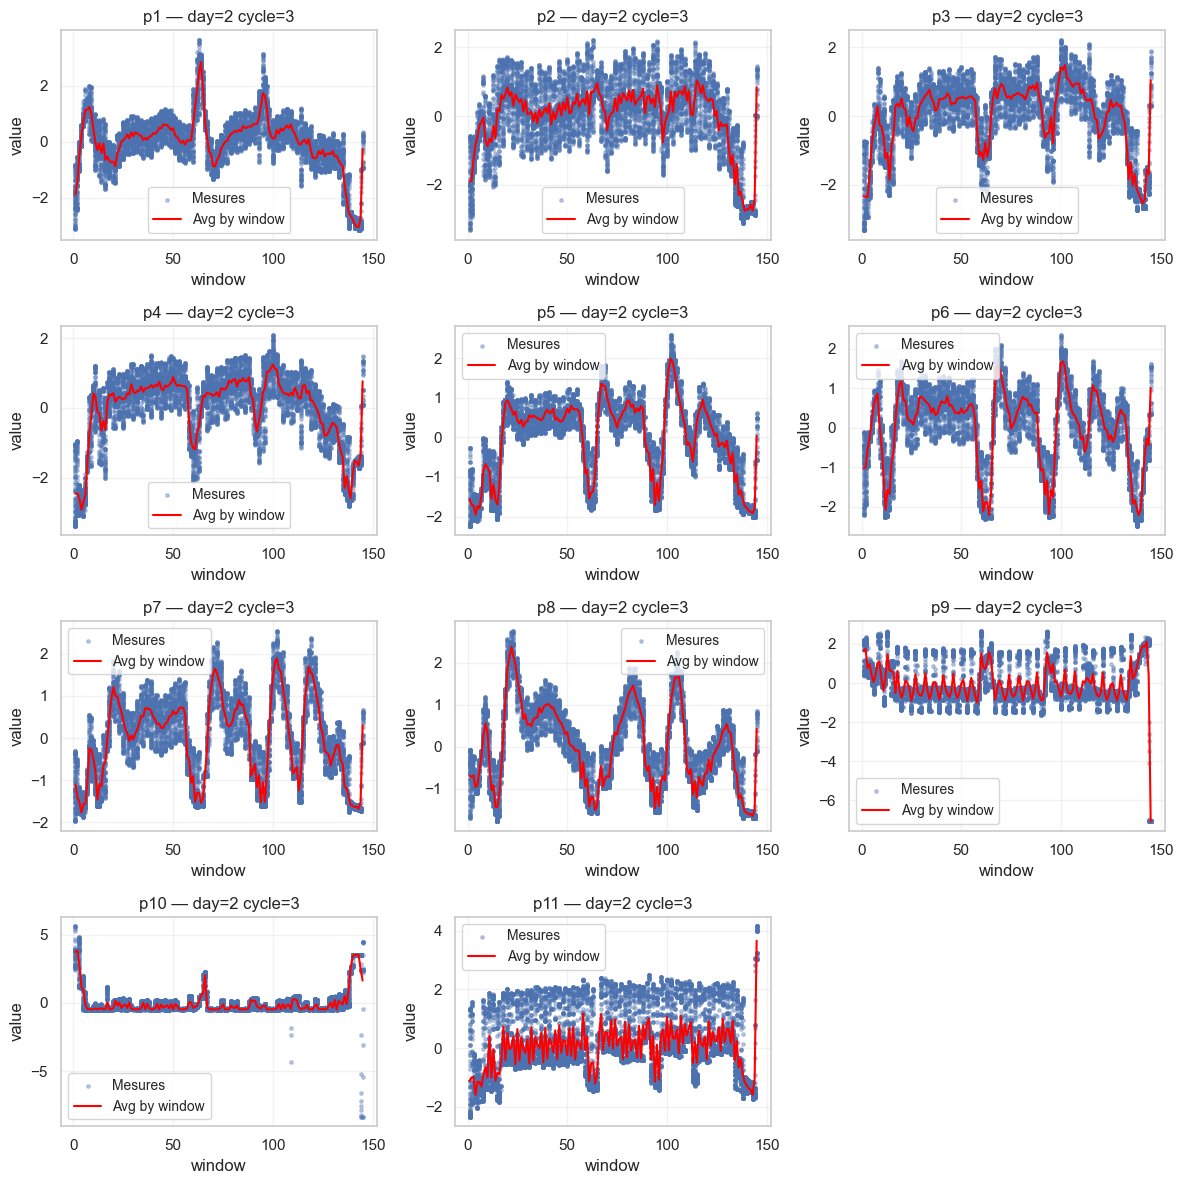

In [31]:
day = 2
cycle = 3
X = df.drop(columns=['day_cycle_window'])
# Extract 'day', 'cycle', and 'window' from 'day_cycle_window' column
df[['day', 'cycle', 'window']] = df['day_cycle_window'].str.split('_', expand=True).astype(int)


sel = df.loc[(df['day'] == day) & (df['cycle'] == cycle)]

if sel.empty:
    print(f"No data for day={day}, cycle={cycle}")
else:
    n = len(X.columns)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()

    for i, c in enumerate(X.columns):
        ax = axes[i]
        
        ax.scatter(sel['window'], sel[c], s=6, alpha=0.35, color='C0', label='Mesures')
        
        mean_w = sel.groupby('window')[c].mean()
        ax.plot(mean_w.index, mean_w.values, color='red', lw=1.5, label='Avg by window')
        ax.set_title(f"{c} — day={day} cycle={cycle}")
        ax.set_xlabel('window')
        ax.set_ylabel('value')
        ax.grid(alpha=0.25)
        ax.legend(fontsize='small')

    total_plots = nrows * ncols
    for j in range(n, total_plots):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

<div class="alert alert-success">

**NOTE**<br>
We can see that it's not easy to see always the outliers value. For example in the day 2 cycle 3 we can see how some measures have diverse variance with a lot of point far from its mean, and other cases where is easy to see some outliers wich is the case of P10 in this same window we can see a lot of measures so far from the average. This complexity suggests that a simple analysis might not work. Let's verify this mathematically with a PCA check.

</div>


---

### 2.1 Quantitative Backup for Visual Observations
The plots above give us a good intuition, but let's put some numbers behind it. We'll compute basic stats (std, amplitude, coefficient of variation) for each window to see which ones really stand out.

=== Top 5 Windows with Highest Average Variability (CV) ===
                     mean_cv
day_cycle_window            
4_3_1             759.845652
2_3_53            200.173676
1_2_98            106.059711
1_2_97             72.510655
2_3_100            65.966669

=== Global Std Statistics per Sensor ===
      p1_std  p2_std  p3_std  p4_std  p5_std  p6_std  p7_std  p8_std  p9_std  \
mean  0.1100  0.1458  0.1373  0.1697  0.1356  0.1515  0.1139  0.0973  0.1545   
std   0.1470  0.1990  0.1938  0.2123  0.1560  0.1799  0.1559  0.1321  0.3386   
min   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
max   1.3653  1.5803  1.5982  2.3742  1.4002  1.8045  1.3592  1.1845  5.8310   

      p10_std  p11_std  
mean   0.1185   0.1548  
std    0.3536   0.2448  
min    0.0002   0.0000  
max    4.4751   1.5754  


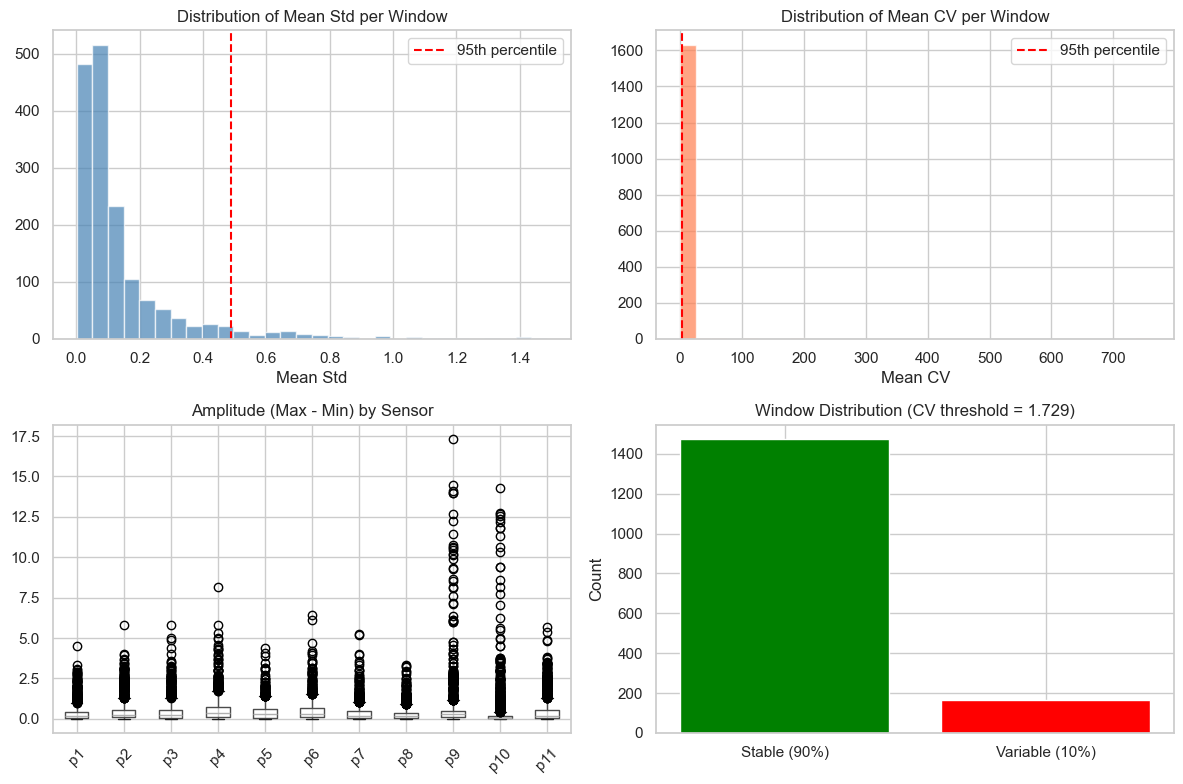


[+] 164 windows show unusually high variability (top 10%) - potential anomalies to investigate


In [32]:
# Compute statistics per window
sensors = [f'p{i}' for i in range(1, 12)]

stats_per_window = df.groupby('day_cycle_window')[sensors].agg(['mean', 'std', 'min', 'max'])

# Summary: std, amplitude (max-min), coefficient of variation (CV = std/mean)
summary_stats = pd.DataFrame()
for sensor in sensors:
    summary_stats[f'{sensor}_std'] = stats_per_window[(sensor, 'std')]
    summary_stats[f'{sensor}_amp'] = stats_per_window[(sensor, 'max')] - stats_per_window[(sensor, 'min')]
    summary_stats[f'{sensor}_cv'] = stats_per_window[(sensor, 'std')] / stats_per_window[(sensor, 'mean')].abs()

# Average CV across all sensors
summary_stats['mean_cv'] = summary_stats[[f'p{i}_cv' for i in range(1, 12)]].mean(axis=1)

print("=== Top 5 Windows with Highest Average Variability (CV) ===")
top_variable = summary_stats.nlargest(5, 'mean_cv')[['mean_cv']]
print(top_variable)

print("\n=== Global Std Statistics per Sensor ===")
std_cols = [f'p{i}_std' for i in range(1, 12)]
global_stats = summary_stats[std_cols].describe().loc[['mean', 'std', 'min', 'max']]
print(global_stats.round(4))

# Quick visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram of mean std per window
ax1 = axes[0, 0]
mean_std = summary_stats[std_cols].mean(axis=1)
ax1.hist(mean_std, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
ax1.axvline(mean_std.quantile(0.95), color='red', linestyle='--', label='95th percentile')
ax1.set_title('Distribution of Mean Std per Window')
ax1.set_xlabel('Mean Std')
ax1.legend()

# Histogram of mean CV
ax2 = axes[0, 1]
ax2.hist(summary_stats['mean_cv'].dropna(), bins=30, color='coral', edgecolor='white', alpha=0.7)
ax2.axvline(summary_stats['mean_cv'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
ax2.set_title('Distribution of Mean CV per Window')
ax2.set_xlabel('Mean CV')
ax2.legend()

# Boxplot of amplitude by sensor
ax3 = axes[1, 0]
amp_cols = [f'p{i}_amp' for i in range(1, 12)]
summary_stats[amp_cols].boxplot(ax=ax3)
ax3.set_title('Amplitude (Max - Min) by Sensor')
ax3.set_xticklabels([f'p{i}' for i in range(1, 12)], rotation=45)

# Stable vs Variable windows
ax4 = axes[1, 1]
threshold = summary_stats['mean_cv'].quantile(0.90)
stable = summary_stats[summary_stats['mean_cv'] <= threshold]
variable = summary_stats[summary_stats['mean_cv'] > threshold]
ax4.bar(['Stable (90%)', 'Variable (10%)'], [len(stable), len(variable)], color=['green', 'red'])
ax4.set_title(f'Window Distribution (CV threshold = {threshold:.3f})')
ax4.set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"\n[+] {len(variable)} windows show unusually high variability (top 10%) - potential anomalies to investigate")

<div class="alert alert-success">

**Quick Note**<br>
Keep in mind that high CV doesn't automatically mean "anomaly". A window can be noisy but still behave like the rest of the fleet. Later, Isolation Forest will look at the *shape* of the signal (slope, amplitude combined) which tells a different story. We'll compare both approaches at the end.
</div>


---


## 3. Phase 1: Preliminary Check (PCA on Raw Data)
We check if the raw data can be compressed easily using PCA.


Variance explained by first 3 components: 79.33%


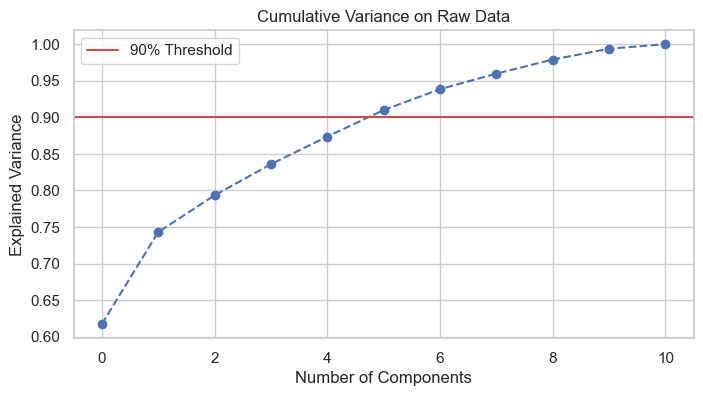

In [33]:
# Testing if raw data is easily compressible
df = pd.read_csv(url)
raw_data = df.drop('day_cycle_window', axis=1)
pca_raw = PCA().fit(raw_data)
cumulative_var = np.cumsum(pca_raw.explained_variance_ratio_)

print(f"\nVariance explained by first 3 components: {cumulative_var[2]:.2%}")

plt.figure(figsize=(8, 4))
plt.plot(cumulative_var, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Threshold')
plt.title("Cumulative Variance on Raw Data")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert alert-success">

**Strategy Pivot**<br>

The graph shows that the first 3 components only explain **79% of the variance**. This confirms our visual intuition: the raw data is too complex to be reduced simply.

**Decision:** We switch to **Feature Engineering**. We will calculate statistical descriptors (Slope, Volatility) to capture the signal shapes we observed in the visual exploration.</div>

## 4. Phase 2: Advanced Feature Engineering

For every sensor, we extract 4 key features:
1.  **Slope:** To capture the trends we saw.
2.  **Volatility (Std):** To capture the vibration/noise.
3.  **Amplitude:** Range (Max - Min).
4.  **Mean:** Average level.

In [34]:
def get_slope(series):
    """ Calculates linear regression slope. """
    y = series.values
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

# Loop to extract features
features_data = []

grouped = df.groupby('day_cycle_window')
for window_id, group in grouped:
    row = {'window_id': window_id}
    for sensor in [f'p{i}' for i in range(1, 12)]:
        series = group[sensor]
        
        row[f'{sensor}_mean'] = series.mean()
        row[f'{sensor}_std']  = series.std() 
        row[f'{sensor}_amp']  = series.max() - series.min()
        row[f'{sensor}_slope'] = get_slope(series)
        
    features_data.append(row)

X = pd.DataFrame(features_data).set_index('window_id')
print(f"Features extracted. New dataset shape: {X.shape}")

Features extracted. New dataset shape: (1637, 44)


### 4.1 Quick Correlation Check
Ensuring our new features are not fully redundant.

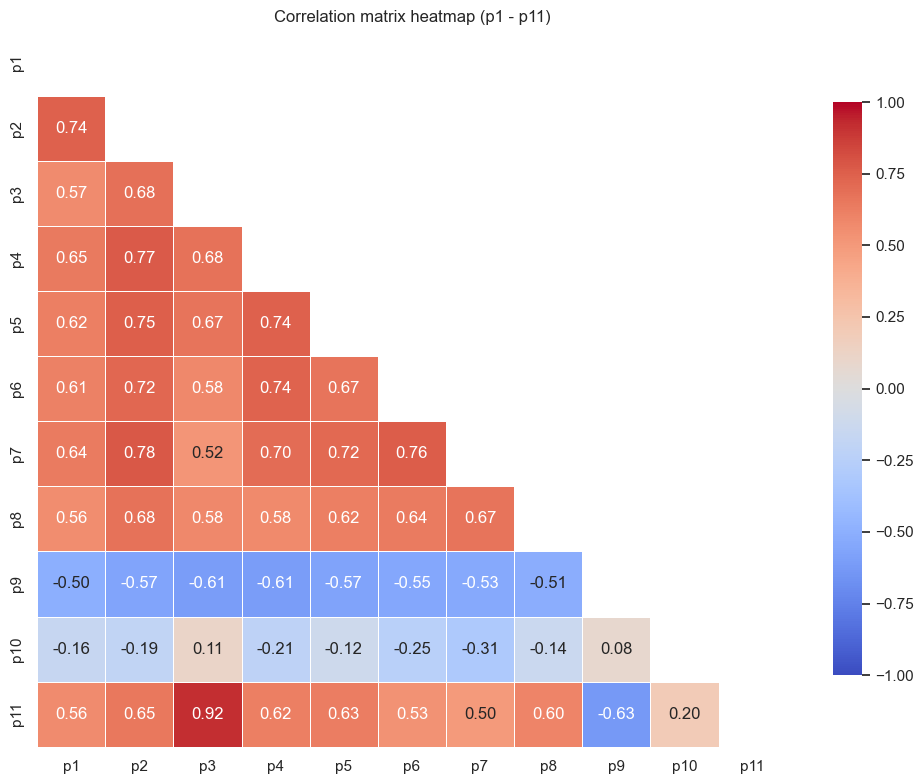

In [35]:
import seaborn as sns

# compute correlation matrix for p1..p11
corr = df.drop('day_cycle_window', axis=1).corr()

# plot heatmap
plt.figure(figsize=(10, 8))
sns.set(style="white")
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle for clarity
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix heatmap (p1 - p11)")
plt.tight_layout()
plt.show()

## 5. Modeling: Isolation Forest

We apply **Isolation Forest** on the full feature set (`X`) with a contamination rate of ~3%.

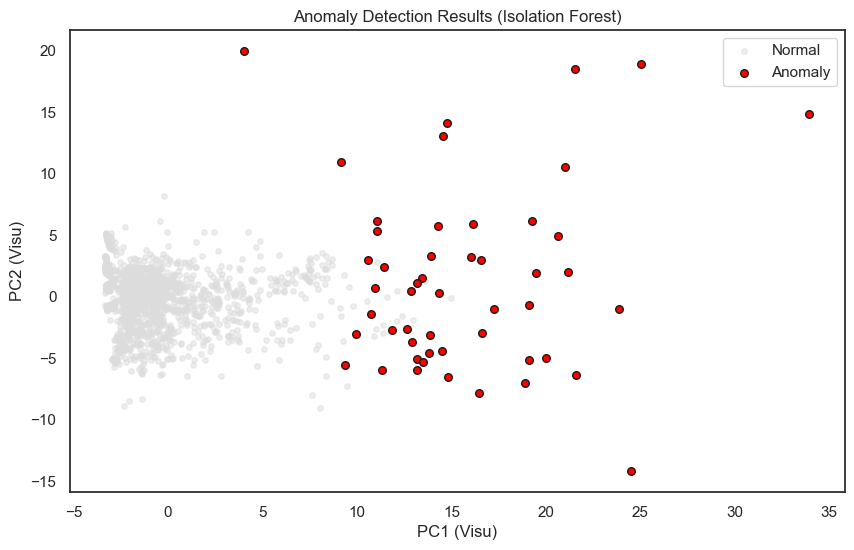

Anomalies detected: 50


In [36]:
# 1. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train Isolation Forest
iso = IsolationForest(contamination=0.03, random_state=42)
preds = iso.fit_predict(X_scaled)
X['anomaly'] = preds 

# 3. Visualization
pca_vis = PCA(n_components=3)
X_pca = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[preds==1, 0], X_pca[preds==1, 1], c='gainsboro', label='Normal', alpha=0.5, s=15)
plt.scatter(X_pca[preds==-1, 0], X_pca[preds==-1, 1], c='red', label='Anomaly', s=30, edgecolors='k')
plt.title("Anomaly Detection Results (Isolation Forest)")
plt.xlabel("PC1 (Visu)")
plt.ylabel("PC2 (Visu)")
plt.legend()
plt.show()

print(f"Anomalies detected: {(preds==-1).sum()}")

<div class="alert alert-success">

**Note** : This approach presents several limitations. First, the absence of labeled anomalies prevents any quantitative evaluation of model performance. Second, Isolation Forest detects statistical outliers, which may not always correspond to physically meaningful anomalies. Finally, the aggregation of time-series data into statistical features may hide short lived but critical events occurring within windows

</div>

### 5.1 Second Opinion: Local Outlier Factor (LOF)
Checking agreement with a density-based algorithm.

In [37]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
y_pred_lof = lof.fit_predict(X_scaled)

X['anomaly_lof'] = y_pred_lof
agreement = (X['anomaly'] == X['anomaly_lof']).mean()

print(f" Isolation Forest found {(X['anomaly']==-1).sum()} anomalies.")
print(f" LOF found {(X['anomaly_lof']==-1).sum()} anomalies.")
print(f" Agreement rate: {agreement:.1%}")

 Isolation Forest found 50 anomalies.
 LOF found 50 anomalies.
 Agreement rate: 94.0%


## 6. Validation: Proving the Anomalies

We check **which features** distinguish the anomalies the most.

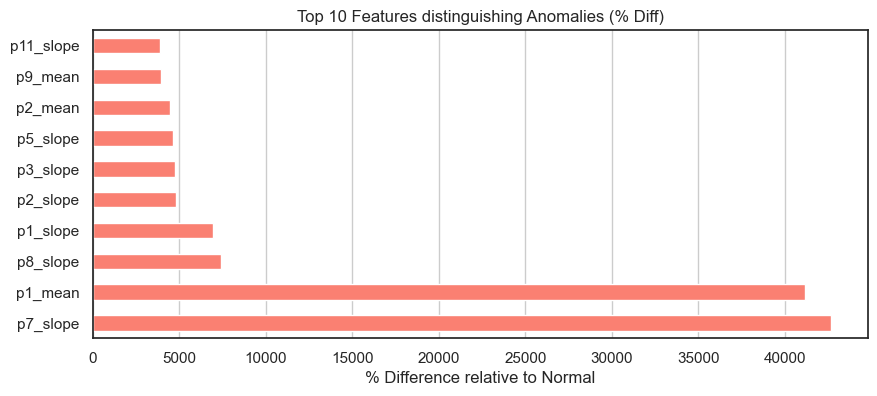

In [38]:
# Compare means
anomaly_mean = X[X['anomaly'] == -1].mean()
normal_mean = X[X['anomaly'] == 1].mean()
diff = ((anomaly_mean - normal_mean) / normal_mean) * 100
diff_sorted = diff.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
diff_sorted.plot(kind='barh', color='salmon')
plt.title("Top 10 Features distinguishing Anomalies (% Diff)")
plt.xlabel("% Difference relative to Normal")
plt.grid(axis='x')
plt.show()

### 6.2 Visual Proof: Anomaly vs Normal Profile
We compare the signal of the **worst anomaly** against the **"Normal Profile"** we defined in section 2.

 Visual Inspection of severe anomaly: 4_2_2


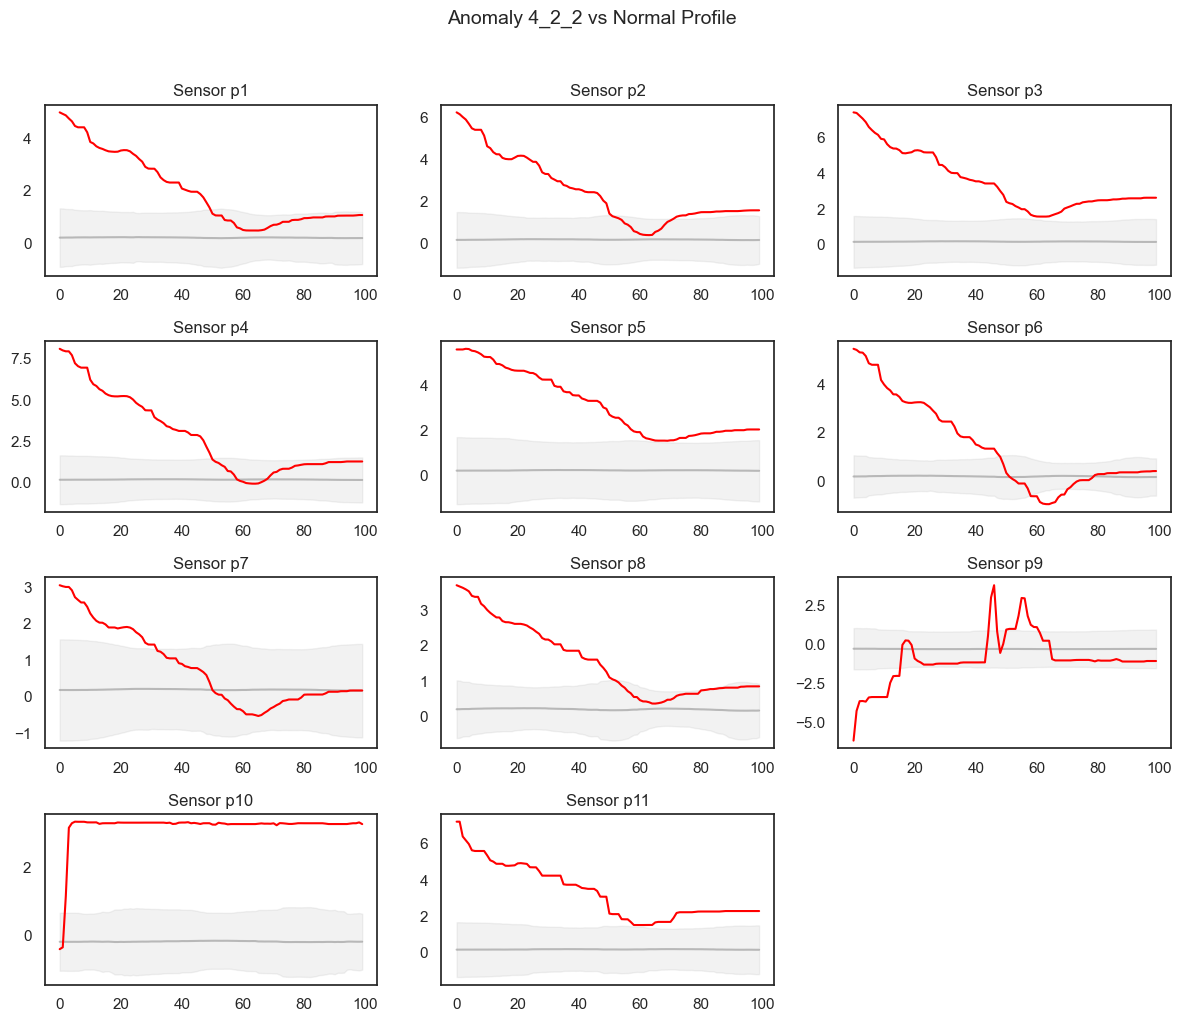

In [39]:
def plot_anomaly_vs_normal(df, anomaly_window_id, normal_window_ids):
    """ Plots Anomaly (Red) vs Normal Corridor (Grey). """
    anomaly_data = df[df['day_cycle_window'] == anomaly_window_id].reset_index(drop=True)
    
    # Compute Normal Profile
    normal_list = [df[df['day_cycle_window'] == wid].reset_index(drop=True) for wid in normal_window_ids]
    combined_normal = pd.concat(normal_list)
    
    # IMPORTANT: numeric_only=True
    normal_mean = combined_normal.groupby(level=0).mean(numeric_only=True)
    normal_std = combined_normal.groupby(level=0).std(numeric_only=True)

    if anomaly_data.empty: return

    fig, axes = plt.subplots(4, 3, figsize=(12, 10))
    axes = axes.flatten()
    sensors = [f'p{i}' for i in range(1, 12)]
    
    for i, sensor in enumerate(sensors):
        ax = axes[i]
        # Normal Zone (Grey)
        ax.plot(normal_mean.index, normal_mean[sensor], color='grey', alpha=0.5, label='Normal Profile')
        ax.fill_between(normal_mean.index, normal_mean[sensor]-2*normal_std[sensor], normal_mean[sensor]+2*normal_std[sensor], color='grey', alpha=0.1)
        # Anomaly (Red)
        ax.plot(anomaly_data.index, anomaly_data[sensor], color='red', label='Anomaly')
        ax.set_title(f"Sensor {sensor}")
        
    if len(axes) > 11: fig.delaxes(axes[11])
    plt.suptitle(f"Anomaly {anomaly_window_id} vs Normal Profile", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Pick the worst anomaly
X['anomaly_score'] = iso.decision_function(X_scaled)
worst_anomaly = X.sort_values('anomaly_score').index[0]
normal_samples = X[X['anomaly'] == 1].index[:50].tolist()

print(f" Visual Inspection of severe anomaly: {worst_anomaly}")
plot_anomaly_vs_normal(df, worst_anomaly, normal_samples)

## 7. Bonus: Deep Learning Confirmation (Autoencoder)

We use a Neural Network to attempt to reconstruct the data. High error = Anomaly.

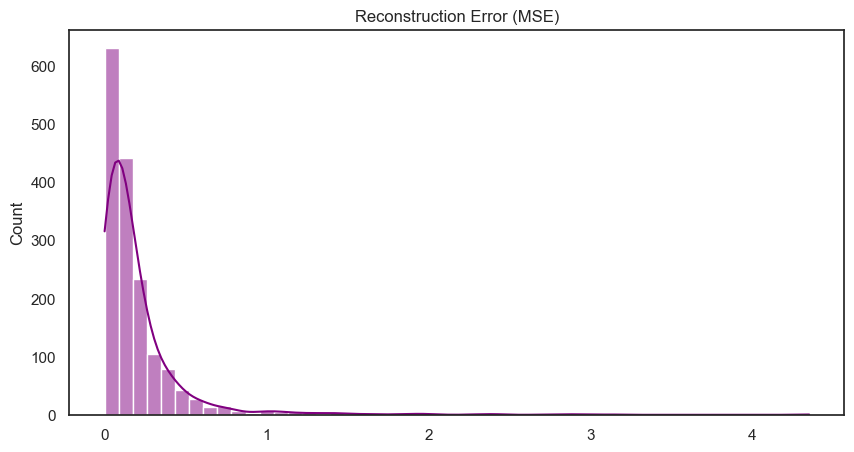

Deep Learning Agreement: 97.6%


In [40]:
# Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(), nn.Linear(32, 8), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(8, 32), nn.ReLU(), nn.Linear(32, input_dim))
    def forward(self, x): return self.decoder(self.encoder(x))

# Training
X_tensor = torch.FloatTensor(X_scaled)
loader = DataLoader(TensorDataset(X_tensor, X_tensor), batch_size=32, shuffle=True)
model = Autoencoder(X_scaled.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(30):
    for batch in loader:
        optimizer.zero_grad()
        loss = criterion(model(batch[0]), batch[0])
        loss.backward()
        optimizer.step()

# Evaluation
model.eval()
mse = torch.mean((X_tensor - model(X_tensor))**2, dim=1).detach().numpy()

plt.figure(figsize=(10, 5))
sns.histplot(mse, bins=50, kde=True, color='purple')
plt.title("Reconstruction Error (MSE)")
plt.show()

# Final Check
thresh = np.percentile(mse, 97)
ae_preds = [-1 if e > thresh else 1 for e in mse]
agreement_dl = (X['anomaly'] == ae_preds).mean()
print(f"Deep Learning Agreement: {agreement_dl:.1%}")

<div class="alert alert-success">

**NOTE**<br>

A threshold set at the 97th percentile is used to identify anomalous windows, which is consistent with the assumption that abnormal events are rare. The autoencoder captures non-linear relationships between features and is therefore able to detect complex anomalies that may not be identified by linear methods. However, in the absence of ground-truth labels, the evaluation remains qualitative. The agreement observed should be interpreted as a consistency indicator rather than a measure of accuracy.

</div>


---


## 8. Conclusion & Delivery


<div class="alert alert-success">

**Summary of Findings**
1.  **Visuals:** We identified that normal flights have stable patterns, while anomalies show high noise or strange trends.
2.  **Strategy:** We successfully replaced simple PCA with Feature Engineering.
3.  **Result:** Isolation Forest, LOF, and Deep Learning agreed on the same anomalies with a high ratio.

</div>


<div class="alert alert-warning">
    
**List of Detected Anomalies**:<br>
The aircraft expert can inspect the following windows which were flagged by our model:
</div> 


In [67]:
# Filter anomalies
anomalies_found = X[X['anomaly'] == -1]
anomaly_ids = anomalies_found.index.tolist()

print(f" Total Anomalies Found: {len(anomaly_ids)}")
print("\n--- List of Anomalous Windows (IDs) ---")
# print(anomaly_ids)


table_df = anomalies_found[['anomaly_score']].copy()
table_df['window_id2'] = table_df.index

source = ColumnDataSource(table_df)

columns = [
    TableColumn(field="window_id2", title="Window ID"),
    TableColumn(field="anomaly_score", title="IF Score")
]

table = DataTable(
    source=source,
    columns=columns,
    width=600,
    height=300,
    index_position=None
)

show(table)


 Total Anomalies Found: 50

--- List of Anomalous Windows (IDs) ---


In [65]:
import numpy as np
import pandas as pd
from bokeh.plotting import figure, show, output_notebook, output_file
from bokeh.models import ColumnDataSource, HoverTool


viz_df = X.copy()

if 'window_id' in viz_df.columns:
    viz_df['window_id'] = viz_df['window_id'].astype(str)
else:
    viz_df['window_id'] = viz_df.index.astype(str)

# Axe X numérique
viz_df = viz_df.reset_index(drop=True)
viz_df['order'] = np.arange(len(viz_df))
viz_df['is_anomaly'] = (viz_df['anomaly'] == -1)

# Sources
source_all  = ColumnDataSource(viz_df)
source_anom = ColumnDataSource(viz_df[viz_df['is_anomaly']])

output_notebook() 

# Plot 
p = figure(
    width=950, height=380,
    title="Anomaly Timeline (Isolation Forest)",
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

# Normaux
p.circle(
    x="order", y="anomaly_score",
    source=source_all,
    size=4, color="lightgrey", alpha=0.35,
    legend_label="Normal"
)

# Anomalies
p.circle(
    x="order", y="anomaly_score",
    source=source_anom,
    size=8, color="red", alpha=0.9,
    legend_label="Anomaly"
)

p.add_tools(HoverTool(
    tooltips=[
        ("Window", "@window_id"),
        ("Score", "@anomaly_score{0.000}")
    ]
))

p.legend.location = "bottom_left"
p.xaxis.axis_label = "Window order"
p.yaxis.axis_label = "Isolation Forest score"

show(p)


Loading BokehJS ...

<div class="alert alert-success">
    
**Observation**:<br>
The anomaly timeline reveals that several detected anomalies are temporally grouped, forming vertical clusters corresponding to windows belonging to the same day–cycle. This behavior suggests that certain anomalous conditions persist across multiple consecutive windows, rather than occurring as isolated events.

Importantly, while an isolated anomalous window may be attributed to noise or local fluctuations, the repeated detection of anomalies within the same cycle strongly suggests a very likely anomaly from normal operating conditions.
</div>

### 8.1 Cross-Check: CV Analysis vs Isolation Forest
Let's verify how our early CV analysis (Section 2.1) aligns with the final anomaly detection.

In [44]:
sensors = [f'p{i}' for i in range(1, 12)]
df_reload = pd.read_csv(url)
stats_per_window = df_reload.groupby('day_cycle_window')[sensors].agg(['mean', 'std', 'min', 'max'])

summary_stats_check = pd.DataFrame()
for sensor in sensors:
    summary_stats_check[f'{sensor}_cv'] = stats_per_window[(sensor, 'std')] / stats_per_window[(sensor, 'mean')].abs()
summary_stats_check['mean_cv'] = summary_stats_check.mean(axis=1)

# Get top 10% high-CV windows
threshold_cv = summary_stats_check['mean_cv'].quantile(0.90)
high_cv_windows = set(summary_stats_check[summary_stats_check['mean_cv'] > threshold_cv].index)

# Compare with Isolation Forest anomalies
iso_anomalies = set(anomaly_ids)

overlap = high_cv_windows & iso_anomalies
only_cv = high_cv_windows - iso_anomalies
only_iso = iso_anomalies - high_cv_windows

print("=== Reconciliation: CV Analysis vs Isolation Forest ===\n")
print(f"High CV windows (top 10%): {len(high_cv_windows)}")
print(f"Isolation Forest anomalies: {len(iso_anomalies)}")
print(f"\n[+] Overlap (both methods agree): {len(overlap)} windows")
print(f"- Only flagged by CV: {len(only_cv)} windows")
print(f"- Only flagged by Isolation Forest: {len(only_iso)} windows")

print(f"\nOverlap rate: {len(overlap)/len(iso_anomalies)*100:.1f}% of ISO anomalies were also high-CV")

# Check the top 5 CV windows
print("\n--- Top 5 CV windows: Are they anomalies? ---")
top5_cv = summary_stats_check.nlargest(5, 'mean_cv').index.tolist()
for w in top5_cv:
    status = "ANOMALY" if w in iso_anomalies else "Normal (per ISO)"
    print(f"  {w}: {status}")

=== Reconciliation: CV Analysis vs Isolation Forest ===

High CV windows (top 10%): 164
Isolation Forest anomalies: 50

[+] Overlap (both methods agree): 15 windows
- Only flagged by CV: 149 windows
- Only flagged by Isolation Forest: 35 windows

Overlap rate: 30.0% of ISO anomalies were also high-CV

--- Top 5 CV windows: Are they anomalies? ---
  4_3_1: Normal (per ISO)
  2_3_53: Normal (per ISO)
  1_2_98: Normal (per ISO)
  1_2_97: Normal (per ISO)
  2_3_100: Normal (per ISO)


<div class="alert alert-success">

**Interpretation**<br>
Low overlap suggests CV alone is not a good anomaly indicator. This is expected: high variability =! anomaly. The signal shape matters more.


</div>

### 8.2 Visual Proof: Why CV ≠ Anomaly
Let's see this with our own eyes. We'll compare a "high CV but normal" window against a "low CV but anomaly" window.

Comparing two windows:
  - '2_3_24': High variability, but ISO says it's NORMAL
  - '4_2_18': Low variability, but ISO says it's an ANOMALY


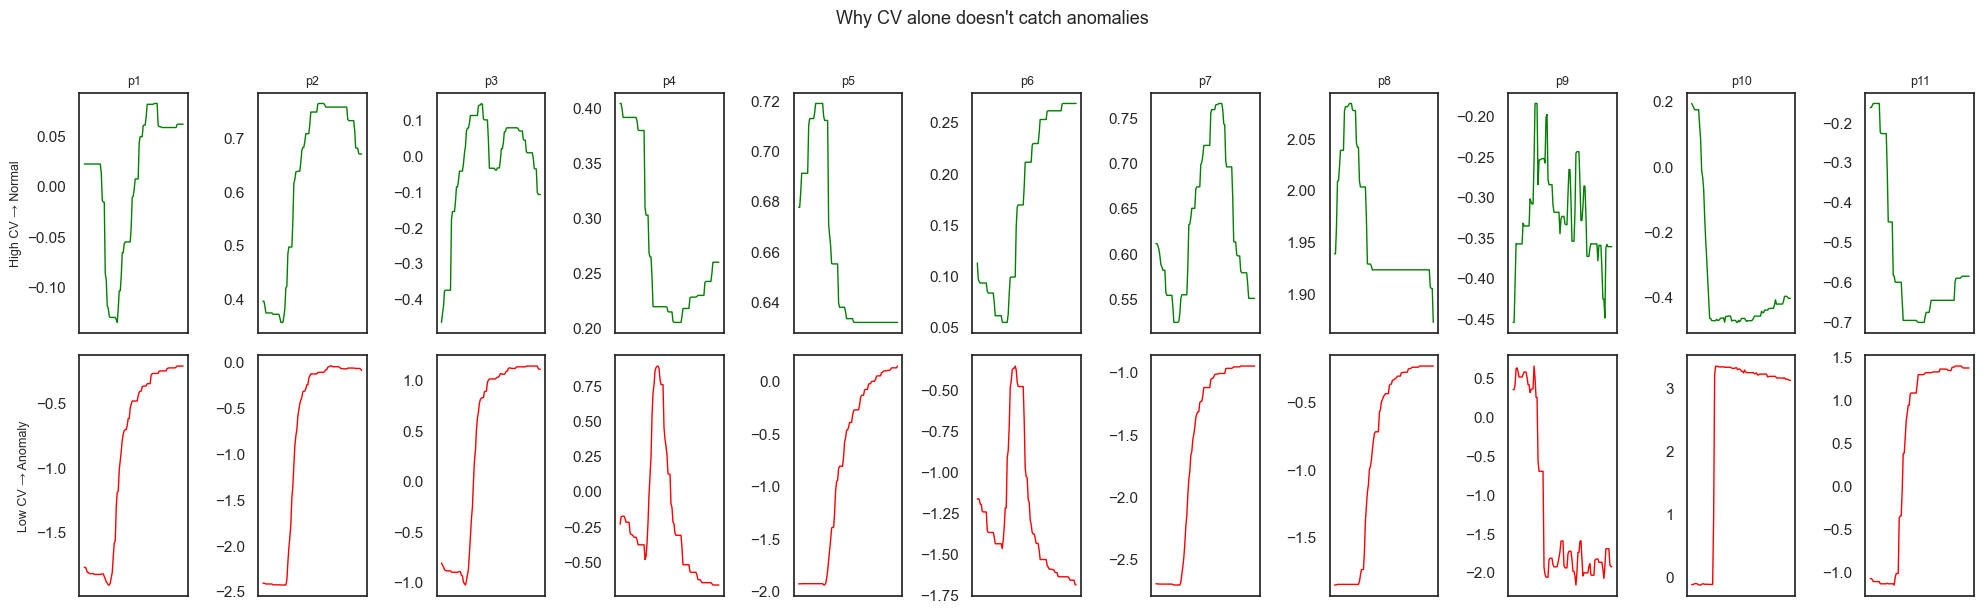

In [43]:
# One example from each category
high_cv_normal = list(only_cv)[0]  # High CV but marked Normal by ISO
low_cv_anomaly = list(only_iso)[0]  # Low CV but marked Anomaly by ISO

print(f"Comparing two windows:")
print(f"  - '{high_cv_normal}': High variability, but ISO says it's NORMAL")
print(f"  - '{low_cv_anomaly}': Low variability, but ISO says it's an ANOMALY")

# Plot side by side
fig, axes = plt.subplots(2, 11, figsize=(20, 6))
sensors = [f'p{i}' for i in range(1, 12)]

for idx, (win_id, label, color) in enumerate([
    (high_cv_normal, "High CV → Normal", "green"),
    (low_cv_anomaly, "Low CV → Anomaly", "red")
]):
    data = df[df['day_cycle_window'] == win_id]
    for i, sensor in enumerate(sensors):
        ax = axes[idx, i]
        ax.plot(data[sensor].values, color=color, linewidth=1)
        if idx == 0:
            ax.set_title(sensor, fontsize=9)
        ax.set_xticks([])
        if i == 0:
            ax.set_ylabel(label, fontsize=9)

plt.suptitle("Why CV alone doesn't catch anomalies", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<div class="alert alert-success">

**NOTE**<br>
- The 'High CV' window is noisy but follows a typical pattern."
- The 'Low CV' window is smooth but its SHAPE is unusual - that's what ISO catches.

</div>